In [1]:
%pip install pandas openpyxl statsmodels scikit-learn matplotlib scipy numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -----------------------------
# File paths
# -----------------------------
FILE_PATH = "Main_Datasheet_Rem.xlsx"
SHEET_NAME = "Analysis_Data"

OUTPUT_DIR = Path("BD_Election_2026_Next_Stage_Outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

print("Original rows:", len(df))
print("Columns:")
print(df.columns.tolist())

Original rows: 300
Columns:
['Constituency', 'Districts', 'Upazilas', 'Upazila_Count', 'Area_sqkm', 'Population', 'Population_Density', 'Household_Size', 'Literacy_Rate', 'Crime_Units', 'Total_Crime_per_100k', 'Violent_Crime_per_100k', 'Election_Status', 'Winner', 'Winning_Party', 'Winning_Party_Code', 'Winner_Votes', 'Winner_Vote_Share', 'Runner_Up', 'Runner_Up_Votes', 'Runner_Up_Vote_Share', 'Margin_Votes', 'Margin_Percentage', 'Competitiveness', 'Metro', 'Use_For_Analysis', 'Remittance_HH_Total', 'CHECK', 'Remittance_HH_Urban']


In [3]:
# Find remittance-related columns
remit_cols = [col for col in df.columns if "remit" in str(col).lower()]

print("Remittance-related columns found:")
for col in remit_cols:
    print(repr(col))

# Choose the raw remittance column manually from the printed list
# Replace this name if your column name is slightly different
raw_remit_col = "Remittance_HH_Total"

# Clean and convert to numeric
df[raw_remit_col] = (
    df[raw_remit_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df[raw_remit_col] = pd.to_numeric(df[raw_remit_col], errors="coerce")

# Create logged remittance variable
df["Log_Remittance_HH_Total"] = np.log1p(df[raw_remit_col])

print(df[[raw_remit_col, "Log_Remittance_HH_Total"]].head())
print("Missing log remittance:", df["Log_Remittance_HH_Total"].isna().sum())

Remittance-related columns found:
'Remittance_HH_Total'
'Remittance_HH_Urban'
   Remittance_HH_Total  Log_Remittance_HH_Total
0                13393                 9.502562
1                13393                 9.502562
2                13393                 9.502562
3                13393                 9.502562
4                 4106                 8.320448
Missing log remittance: 0


In [4]:
# Excluded constituencies from your final analysis sample
excluded_constituencies = ["Chittagong-2", "Chittagong-4", "Sherpur-3"]

df = df[~df["Constituency"].isin(excluded_constituencies)].copy()

# Variables used in Model 3
dependent_var = "Margin_Percentage"

predictors = [
    "Population_Density",
    "Household_Size",
    "Literacy_Rate",
    "Total_Crime_per_100k",
    "Violent_Crime_per_100k",
    "Metro",
    "Log_Remittance_HH_Total"
]

required_cols = ["Constituency", dependent_var] + predictors

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Convert Metro to numeric if needed
if df["Metro"].dtype == "object":
    df["Metro"] = (
        df["Metro"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "metro": 1,
            "non-metro": 0,
            "yes": 1,
            "no": 0,
            "1": 1,
            "0": 0,
            "true": 1,
            "false": 0
        })
    )

# Convert numeric columns
for col in [dependent_var] + predictors:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Final model dataset
model_df = df[required_cols].dropna().copy()

print("Final analysis rows:", len(model_df))
print(model_df[[dependent_var] + predictors].describe())

Final analysis rows: 297
       Margin_Percentage  Population_Density  Household_Size  Literacy_Rate  \
count         297.000000          297.000000      297.000000     297.000000   
mean           20.141163         3200.938387        4.037373      74.029924   
std            15.517316         7395.352866        0.389775       6.595227   
min             0.183816          111.766947        3.080000      54.660000   
25%             7.720500          821.133793        3.760000      68.920152   
50%            16.737117         1118.347945        3.980000      74.050000   
75%            27.809602         1610.822194        4.190000      78.703098   
max            73.173058        33704.756605        5.294522      88.830000   

       Total_Crime_per_100k  Violent_Crime_per_100k       Metro  \
count            297.000000              297.000000  297.000000   
mean              94.295230               13.556908    0.114478   
std               11.992499                3.024780    0.31892

In [5]:
y = model_df[dependent_var]
X = sm.add_constant(model_df[predictors])

model3 = sm.OLS(y, X).fit(cov_type="HC3")

print(model3.summary())

# Save Model 3 results
model3_results = pd.DataFrame({
    "variable": model3.params.index,
    "coefficient": model3.params.values,
    "robust_se_HC3": model3.bse.values,
    "t_value": model3.tvalues.values,
    "p_value": model3.pvalues.values,
    "ci_lower": model3.conf_int()[0].values,
    "ci_upper": model3.conf_int()[1].values
})

model3_results["n"] = int(model3.nobs)
model3_results["r_squared"] = model3.rsquared
model3_results["adj_r_squared"] = model3.rsquared_adj

model3_results.to_csv(OUTPUT_DIR / "OLS_Model_3_Margin_Remittance_Robust_Results.csv", index=False)

model3_results

                            OLS Regression Results                            
Dep. Variable:      Margin_Percentage   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     6.036
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.39e-06
Time:                        03:10:42   Log-Likelihood:                -1218.7
No. Observations:                 297   AIC:                             2453.
Df Residuals:                     289   BIC:                             2483.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

,variable,coefficient,robust_se_HC3,t_value,p_value,ci_lower,ci_upper,n,r_squared,adj_r_squared
0,const,37.222644,27.892566,1.334501,0.182040,-17.445781,91.891068,297,0.105482,0.083815
1,Population_Density,-0.000329,0.000150,-2.189108,0.028589,-0.000624,-0.000034,297,0.105482,0.083815
2,Household_Size,1.242849,2.675507,0.464529,0.642269,-4.001047,6.486746,297,0.105482,0.083815
3,Literacy_Rate,-0.100031,0.169084,-0.591607,0.554114,-0.431430,0.231367,297,0.105482,0.083815
4,Total_Crime_per_100k,-0.328535,0.117821,-2.788432,0.005296,-0.559459,-0.097611,297,0.105482,0.083815
5,Violent_Crime_per_100k,0.433274,0.367216,1.179889,0.238044,-0.286456,1.153005,297,0.105482,0.083815
6,Metro,-2.893533,3.845355,-0.752475,0.451766,-10.430290,4.643225,297,0.105482,0.083815
7,Log_Remittance_HH_Total,1.094166,1.218775,0.897759,0.369314,-1.294590,3.482922,297,0.105482,0.083815


In [6]:
X_vif = sm.add_constant(model_df[predictors])

vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_table = vif_table[vif_table["variable"] != "const"].reset_index(drop=True)

vif_table.to_csv(OUTPUT_DIR / "OLS_Model_3_Margin_Remittance_VIF.csv", index=False)

vif_table

,variable,VIF
0,Population_Density,2.513403
1,Household_Size,1.647589
2,Literacy_Rate,1.523914
3,Total_Crime_per_100k,2.601121
4,Violent_Crime_per_100k,1.754398
5,Metro,2.390961
6,Log_Remittance_HH_Total,1.870715


In [7]:
# Cell 5 — diagnostics tests

In [8]:
# Non-robust version used for diagnostic objects
model3_base = sm.OLS(y, X).fit()

residuals = model3_base.resid
fitted = model3_base.fittedvalues

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X)

# Jarque-Bera test
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

# Ramsey RESET test
reset_test = linear_reset(model3_base, power=2, use_f=True)

diagnostics_summary = pd.DataFrame({
    "test": [
        "Breusch-Pagan LM",
        "Breusch-Pagan F",
        "Jarque-Bera",
        "Ramsey RESET"
    ],
    "statistic": [
        bp_test[0],
        bp_test[2],
        jb_stat,
        float(reset_test.fvalue)
    ],
    "p_value": [
        bp_test[1],
        bp_test[3],
        jb_pvalue,
        float(reset_test.pvalue)
    ]
})

diagnostics_summary.to_csv(OUTPUT_DIR / "Model_3_Diagnostics_Summary.csv", index=False)

diagnostics_summary

,test,statistic,p_value
0,Breusch-Pagan LM,13.582113,5.913308e-02
1,Breusch-Pagan F,1.978517,5.788241e-02
2,Jarque-Bera,39.532309,2.604163e-09
3,Ramsey RESET,0.335700,5.627748e-01


In [9]:
# Cell 6 — diagnostic plots

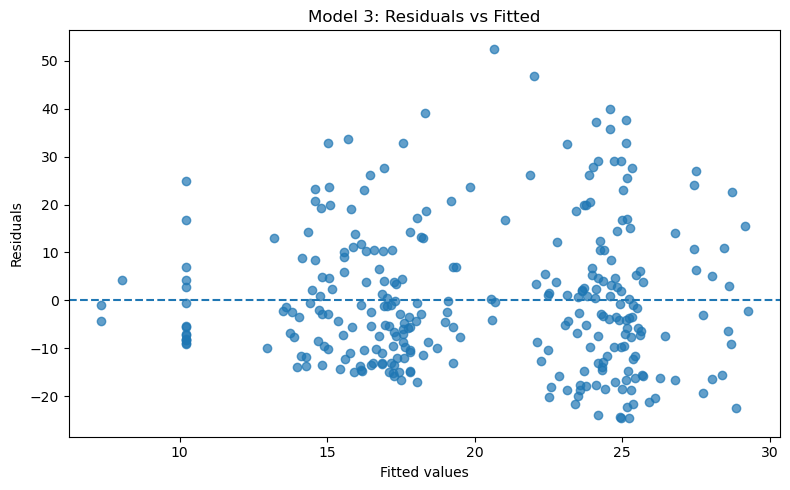

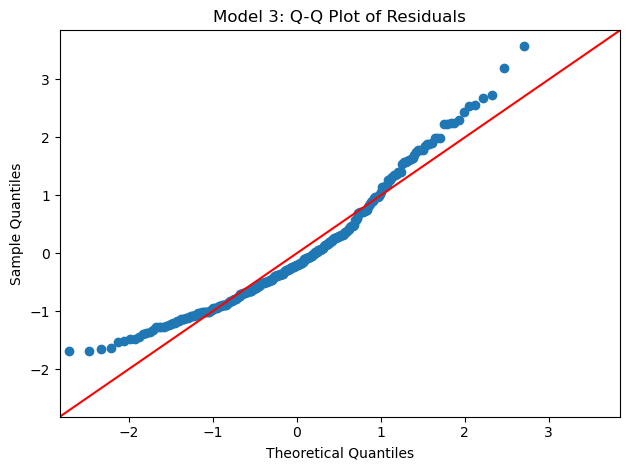

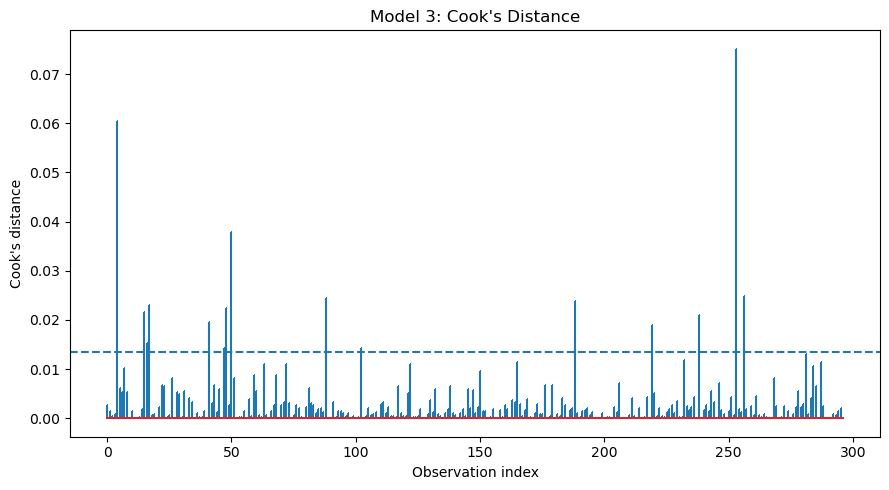

In [10]:
# Residuals vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Model 3: Residuals vs Fitted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Model_3_Diagnostic_Residuals_vs_Fitted.png", dpi=300)
plt.show()

# Q-Q plot
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Model 3: Q-Q Plot of Residuals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Model_3_Diagnostic_QQ_Plot.png", dpi=300)
plt.show()

# Cook's distance
influence = model3_base.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(9, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4 / len(model_df), linestyle="--")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Model 3: Cook's Distance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Model_3_Diagnostic_Cooks_Distance.png", dpi=300)
plt.show()

In [11]:
# Cell 7 — influential observations

In [12]:
model_df_influence = model_df.copy()
model_df_influence["fitted"] = fitted
model_df_influence["residual"] = residuals
model_df_influence["cooks_distance"] = cooks_d

cook_threshold = 4 / len(model_df)

influential_obs = (
    model_df_influence
    .sort_values("cooks_distance", ascending=False)
    .head(20)
)

influential_obs.to_csv(OUTPUT_DIR / "Model_3_Top_Influential_Observations.csv", index=False)

print("Cook's distance threshold:", cook_threshold)
print("Number above threshold:", (model_df_influence["cooks_distance"] > cook_threshold).sum())

influential_obs[["Constituency", dependent_var, "fitted", "residual", "cooks_distance"]]

Cook's distance threshold: 0.013468013468013467
Number above threshold: 15


,Constituency,Margin_Percentage,fitted,residual,cooks_distance
255,Rangamati-1,73.173058,20.660619,52.512439,0.075147
4,Bandarban-1,68.783596,21.996445,46.787151,0.060496
52,Chittagong-8,48.130323,21.890146,26.240177,0.037948
258,Rangpur-3,35.041186,15.083512,19.957673,0.024929
90,Dhaka-9,35.070929,10.232067,24.838862,0.024502
190,Mymensingh-4,2.391854,22.519126,-20.127271,0.023840
17,Bogura-1,49.468829,15.710607,33.758222,0.022952
50,Chittagong-6,61.281246,24.131767,37.149480,0.022452
15,Bhola-3,43.591307,19.831883,23.759424,0.021523
240,Patuakhali-1,44.673909,16.937681,27.736228,0.021051


In [13]:
# Cell 8 — robustness checks

In [14]:
def run_ols_robust(data, y_col, x_cols, model_name):
    y_temp = data[y_col]
    X_temp = sm.add_constant(data[x_cols])
    result = sm.OLS(y_temp, X_temp).fit(cov_type="HC3")
    
    out = pd.DataFrame({
        "model": model_name,
        "variable": result.params.index,
        "coefficient": result.params.values,
        "robust_se_HC3": result.bse.values,
        "t_value": result.tvalues.values,
        "p_value": result.pvalues.values,
        "ci_lower": result.conf_int()[0].values,
        "ci_upper": result.conf_int()[1].values,
        "n": int(result.nobs),
        "r_squared": result.rsquared,
        "adj_r_squared": result.rsquared_adj
    })
    
    return out, result


robustness_results = []

# 1. Baseline Model 3
baseline_out, baseline_model = run_ols_robust(
    model_df,
    dependent_var,
    predictors,
    "Baseline Model 3"
)
robustness_results.append(baseline_out)

# 2. Exclude influential observations
non_influential_df = model_df_influence[model_df_influence["cooks_distance"] <= cook_threshold].copy()

exclude_out, exclude_model = run_ols_robust(
    non_influential_df,
    dependent_var,
    predictors,
    "Excluding influential observations"
)
robustness_results.append(exclude_out)

# 3. Winsorized 1/99
winsor_df = model_df.copy()

winsor_cols = [
    dependent_var,
    "Population_Density",
    "Household_Size",
    "Literacy_Rate",
    "Total_Crime_per_100k",
    "Violent_Crime_per_100k",
    "Log_Remittance_HH_Total"
]

for col in winsor_cols:
    lower = winsor_df[col].quantile(0.01)
    upper = winsor_df[col].quantile(0.99)
    winsor_df[col] = winsor_df[col].clip(lower, upper)

winsor_out, winsor_model = run_ols_robust(
    winsor_df,
    dependent_var,
    predictors,
    "Winsorized 1/99"
)
robustness_results.append(winsor_out)

# 4. Standardized model
standard_df = model_df.copy()

standard_cols = [
    dependent_var,
    "Population_Density",
    "Household_Size",
    "Literacy_Rate",
    "Total_Crime_per_100k",
    "Violent_Crime_per_100k",
    "Log_Remittance_HH_Total"
]

for col in standard_cols:
    standard_df[col] = (standard_df[col] - standard_df[col].mean()) / standard_df[col].std()

standard_out, standard_model = run_ols_robust(
    standard_df,
    dependent_var,
    predictors,
    "Standardized model"
)
robustness_results.append(standard_out)

# 5. Log population density model
log_density_df = model_df.copy()
log_density_df["Log_Population_Density"] = np.log1p(log_density_df["Population_Density"])

log_density_predictors = [
    "Log_Population_Density",
    "Household_Size",
    "Literacy_Rate",
    "Total_Crime_per_100k",
    "Violent_Crime_per_100k",
    "Metro",
    "Log_Remittance_HH_Total"
]

log_density_out, log_density_model = run_ols_robust(
    log_density_df,
    dependent_var,
    log_density_predictors,
    "Log population density"
)
robustness_results.append(log_density_out)

# Combine all robustness results
robustness_all = pd.concat(robustness_results, ignore_index=True)

robustness_all.to_csv(OUTPUT_DIR / "Model_3_Robustness_Results_All.csv", index=False)

# Key predictors only
key_predictors = [
    "Population_Density",
    "Log_Population_Density",
    "Total_Crime_per_100k",
    "Log_Remittance_HH_Total"
]

robustness_key = robustness_all[robustness_all["variable"].isin(key_predictors)].copy()

robustness_key.to_csv(OUTPUT_DIR / "Model_3_Robustness_Key_Predictors.csv", index=False)

robustness_key

,model,variable,coefficient,robust_se_HC3,t_value,p_value,ci_lower,ci_upper,n,r_squared,adj_r_squared
1,Baseline Model 3,Population_Density,-0.000329,0.000150,-2.189108,0.028589,-0.000624,-0.000034,297,0.105482,0.083815
4,Baseline Model 3,Total_Crime_per_100k,-0.328535,0.117821,-2.788432,0.005296,-0.559459,-0.097611,297,0.105482,0.083815
7,Baseline Model 3,Log_Remittance_HH_Total,1.094166,1.218775,0.897759,0.369314,-1.294590,3.482922,297,0.105482,0.083815
9,Excluding influential observations,Population_Density,-0.000325,0.000103,-3.142022,0.001678,-0.000528,-0.000122,282,0.137682,0.115652
12,Excluding influential observations,Total_Crime_per_100k,-0.317364,0.106040,-2.992860,0.002764,-0.525200,-0.109529,282,0.137682,0.115652
15,Excluding influential observations,Log_Remittance_HH_Total,1.704440,0.922141,1.848351,0.064552,-0.102923,3.511803,282,0.137682,0.115652
17,Winsorized 1/99,Population_Density,-0.000329,0.000151,-2.181465,0.029149,-0.000624,-0.000033,297,0.107414,0.085794
20,Winsorized 1/99,Total_Crime_per_100k,-0.318691,0.115265,-2.764853,0.005695,-0.544606,-0.092776,297,0.107414,0.085794
23,Winsorized 1/99,Log_Remittance_HH_Total,1.266211,1.145940,1.104955,0.269179,-0.979789,3.512211,297,0.107414,0.085794
25,Standardized model,Population_Density,-0.156949,0.071695,-2.189108,0.028589,-0.297469,-0.016429,297,0.105482,0.083815


In [15]:
# Cell 9 — standardized coefficient plot

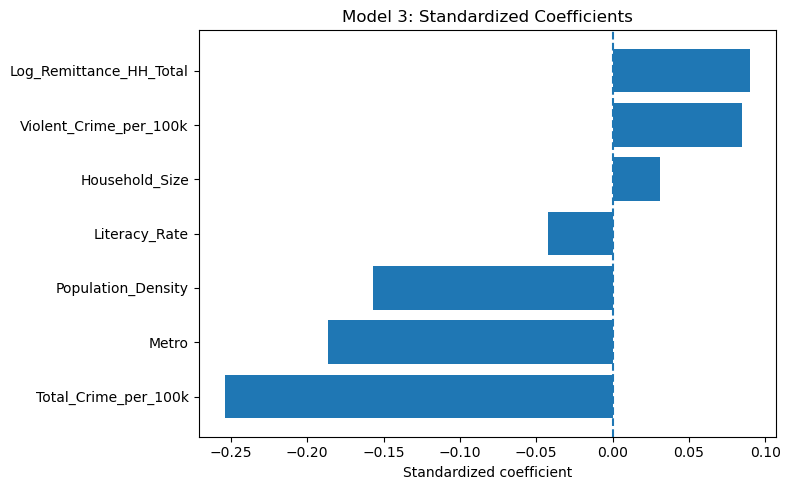

In [16]:
standard_plot_df = standard_out.copy()
standard_plot_df = standard_plot_df[standard_plot_df["variable"] != "const"].copy()
standard_plot_df = standard_plot_df.sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(standard_plot_df["variable"], standard_plot_df["coefficient"])
plt.axvline(0, linestyle="--")
plt.xlabel("Standardized coefficient")
plt.title("Model 3: Standardized Coefficients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Model_3_Standardized_Coefficients.png", dpi=300)
plt.show()

In [17]:
 #  Cell 10 — binary competitiveness/logit model

In [18]:
def prepare_logit_data(data, threshold):
    temp = data.copy()
    temp["Competitive"] = (temp[dependent_var] <= threshold).astype(int)
    
    # Standardize continuous predictors for stable logit coefficients
    continuous_predictors = [
        "Population_Density",
        "Household_Size",
        "Literacy_Rate",
        "Total_Crime_per_100k",
        "Violent_Crime_per_100k",
        "Log_Remittance_HH_Total"
    ]
    
    logit_predictors = []
    
    for col in continuous_predictors:
        z_col = col + "_z"
        temp[z_col] = (temp[col] - temp[col].mean()) / temp[col].std()
        logit_predictors.append(z_col)
    
    logit_predictors.append("Metro")
    
    return temp, logit_predictors


def run_logit(data, threshold):
    temp, logit_predictors = prepare_logit_data(data, threshold)
    
    y_logit = temp["Competitive"]
    X_logit = sm.add_constant(temp[logit_predictors])
    
    logit_model = sm.Logit(y_logit, X_logit).fit(disp=False, maxiter=500)
    
    pred_prob = logit_model.predict(X_logit)
    auc = roc_auc_score(y_logit, pred_prob)
    
    conf = logit_model.conf_int()
    
    out = pd.DataFrame({
        "threshold": threshold,
        "variable": logit_model.params.index,
        "coefficient": logit_model.params.values,
        "std_error": logit_model.bse.values,
        "z_value": logit_model.tvalues.values,
        "p_value": logit_model.pvalues.values,
        "ci_lower": conf[0].values,
        "ci_upper": conf[1].values,
        "odds_ratio": np.exp(logit_model.params.values),
        "or_ci_lower": np.exp(conf[0].values),
        "or_ci_upper": np.exp(conf[1].values),
        "competitive_seats": int(y_logit.sum()),
        "non_competitive_seats": int((1 - y_logit).sum()),
        "auc_in_sample": auc,
        "pseudo_r2": logit_model.prsquared
    })
    
    return out, logit_model, temp, logit_predictors


# Detect whether Margin_Percentage is stored as percentage points or fraction
# Example:
# 5.0 means 5 percentage points
# 0.05 means 5 percentage points as a fraction
if model_df[dependent_var].max() <= 1.5:
    thresholds = [0.05, 0.10, 0.15]
else:
    thresholds = [5, 10, 15]

logit_outputs = []
logit_models = {}

for threshold in thresholds:
    out, fitted_logit, temp_logit_df, logit_predictors = run_logit(model_df, threshold)
    logit_outputs.append(out)
    logit_models[threshold] = fitted_logit

logit_results = pd.concat(logit_outputs, ignore_index=True)

logit_results.to_csv(OUTPUT_DIR / "Binary_Competitiveness_Logit_Results.csv", index=False)

logit_results

,threshold,variable,coefficient,std_error,z_value,p_value,ci_lower,ci_upper,odds_ratio,or_ci_lower,or_ci_upper,competitive_seats,non_competitive_seats,auc_in_sample,pseudo_r2
0,5,const,-1.712168,0.209463,-8.174065,2.981679e-16,-2.122709,-1.301627,0.180474,0.119707,0.272089,51,246,0.724613,0.110333
1,5,Population_Density_z,0.865357,0.292339,2.960114,3.075248e-03,0.292383,1.438332,2.375855,1.339616,4.213660,51,246,0.724613,0.110333
2,5,Household_Size_z,-0.030208,0.247292,-0.122155,9.027764e-01,-0.514891,0.454476,0.970244,0.597565,1.575347,51,246,0.724613,0.110333
3,5,Literacy_Rate_z,0.035956,0.210196,0.171061,8.641761e-01,-0.376021,0.447934,1.036611,0.686588,1.565075,51,246,0.724613,0.110333
4,5,Total_Crime_per_100k_z,0.379911,0.265802,1.429304,1.529170e-01,-0.141050,0.900872,1.462155,0.868446,2.461750,51,246,0.724613,0.110333
5,5,Violent_Crime_per_100k_z,-0.207482,0.212726,-0.975350,3.293867e-01,-0.624417,0.209453,0.812628,0.535574,1.233003,51,246,0.724613,0.110333
6,5,Log_Remittance_HH_Total_z,-0.520537,0.218821,-2.378823,1.736803e-02,-0.949419,-0.091655,0.594201,0.386966,0.912420,51,246,0.724613,0.110333
7,5,Metro,-0.756088,1.053741,-0.717527,4.730489e-01,-2.821383,1.309207,0.469499,0.059524,3.703237,51,246,0.724613,0.110333
8,10,const,-0.815821,0.151943,-5.369242,7.906834e-08,-1.113624,-0.518017,0.442276,0.328367,0.595701,92,205,0.654427,0.058037
9,10,Population_Density_z,0.510578,0.211876,2.409799,1.596129e-02,0.095309,0.925847,1.666254,1.099999,2.524006,92,205,0.654427,0.058037


In [19]:
# Cell 11 — cross-validated AUC for logit model

In [20]:
cv_results = []

for threshold in thresholds:
    temp = model_df.copy()
    temp["Competitive"] = (temp[dependent_var] <= threshold).astype(int)
    
    X_ml = temp[predictors]
    y_ml = temp["Competitive"]
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    auc_scores = cross_val_score(
        pipeline,
        X_ml,
        y_ml,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results.append({
        "threshold": threshold,
        "competitive_seats": int(y_ml.sum()),
        "mean_cv_auc": auc_scores.mean(),
        "std_cv_auc": auc_scores.std(),
        "fold_scores": auc_scores.tolist()
    })

cv_auc_df = pd.DataFrame(cv_results)

cv_auc_df.to_csv(OUTPUT_DIR / "Binary_Competitiveness_Logit_CV_AUC.csv", index=False)

cv_auc_df

,threshold,competitive_seats,mean_cv_auc,std_cv_auc,fold_scores
0,5,51,0.671223,0.072751,"[0.6011131725417439, 0.655, 0.6040816326530611..."
1,10,92,0.616253,0.054094,"[0.6283697047496791, 0.7137355584082157, 0.592..."
2,15,135,0.638065,0.051512,"[0.6167227833894501, 0.6818181818181817, 0.645..."


In [21]:
# Cell 12 — odds-ratio plot for the strict 5pp model

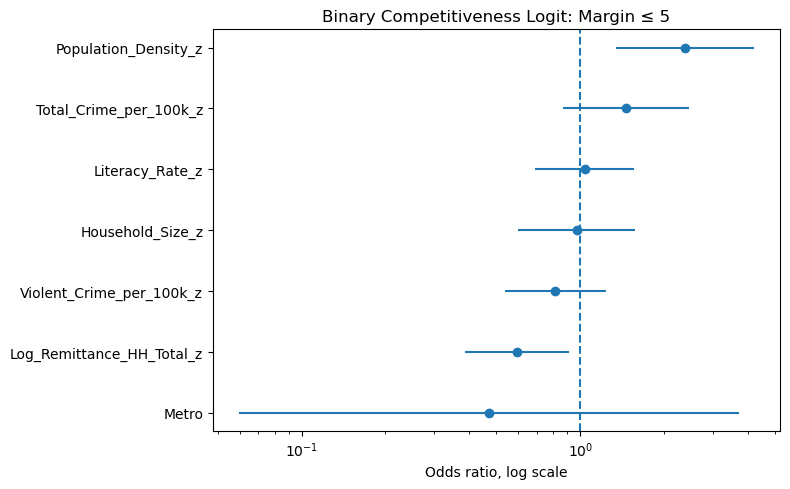

In [22]:
threshold_for_plot = thresholds[0]

or_plot_df = logit_results[
    (logit_results["threshold"] == threshold_for_plot) &
    (logit_results["variable"] != "const")
].copy()

or_plot_df = or_plot_df.sort_values("odds_ratio")

plt.figure(figsize=(8, 5))

plt.errorbar(
    x=or_plot_df["odds_ratio"],
    y=or_plot_df["variable"],
    xerr=[
        or_plot_df["odds_ratio"] - or_plot_df["or_ci_lower"],
        or_plot_df["or_ci_upper"] - or_plot_df["odds_ratio"]
    ],
    fmt="o"
)

plt.axvline(1, linestyle="--")
plt.xscale("log")
plt.xlabel("Odds ratio, log scale")
plt.title(f"Binary Competitiveness Logit: Margin ≤ {threshold_for_plot}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Binary_Competitiveness_Logit_OR_5pp.png", dpi=300)
plt.show()

In [23]:
# Cell 13 — final summary table

In [24]:
summary_table = pd.DataFrame({
    "stage": [
        "Model 3 OLS",
        "VIF",
        "Diagnostics",
        "Influential observations",
        "Robustness checks",
        "Binary competitiveness logit",
        "Cross-validated AUC",
        "Plots"
    ],
    "output_file": [
        "OLS_Model_3_Margin_Remittance_Robust_Results.csv",
        "OLS_Model_3_Margin_Remittance_VIF.csv",
        "Model_3_Diagnostics_Summary.csv",
        "Model_3_Top_Influential_Observations.csv",
        "Model_3_Robustness_Results_All.csv",
        "Binary_Competitiveness_Logit_Results.csv",
        "Binary_Competitiveness_Logit_CV_AUC.csv",
        "PNG files inside output folder"
    ]
})

summary_table.to_csv(OUTPUT_DIR / "BD_Election_2026_Next_Stage_Output_Index.csv", index=False)

summary_table

,stage,output_file
0,Model 3 OLS,OLS_Model_3_Margin_Remittance_Robust_Results.csv
1,VIF,OLS_Model_3_Margin_Remittance_VIF.csv
2,Diagnostics,Model_3_Diagnostics_Summary.csv
3,Influential observations,Model_3_Top_Influential_Observations.csv
4,Robustness checks,Model_3_Robustness_Results_All.csv
5,Binary competitiveness logit,Binary_Competitiveness_Logit_Results.csv
6,Cross-validated AUC,Binary_Competitiveness_Logit_CV_AUC.csv
7,Plots,PNG files inside output folder


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# TABLE 3: COMBINE OLS MODEL 1, MODEL 2, AND MODEL 3 RESULTS
# ============================================================

# ---------- Helper functions ----------

def find_one(pattern):
    """
    Finds one file matching the pattern in the current notebook folder
    and subfolders.
    """
    matches = list(Path(".").rglob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file found for pattern: {pattern}")
    print(f"Using: {matches[0]}")
    return matches[0]


def stars(p):
    """
    Adds significance stars based on p-value.
    """
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


def format_coef_se(row):
    """
    Formats coefficient and robust standard error for LaTeX.
    Example:
    0.1234**
    (0.0456)
    """
    coef = row["Coefficient"]
    se = row["Robust_Std_Error"]
    p = row["P_Value"]
    return f"\\makecell[r]{{{coef:.4f}{stars(p)}\\\\({se:.4f})}}"


def extract_model_stats(df):
    """
    Tries to extract N, R-squared, and adjusted R-squared if available.
    If unavailable, returns blanks.
    """
    stats = {"N": "", "R-squared": "", "Adjusted R-squared": ""}

    possible_n_cols = ["N", "n", "Observations", "observations"]
    possible_r2_cols = ["R_squared", "r_squared", "R-squared", "rsquared"]
    possible_adj_cols = ["Adj_R_squared", "adj_r_squared", "Adjusted_R_squared", "Adj. R-squared", "adj_rsquared"]

    for col in possible_n_cols:
        if col in df.columns:
            try:
                stats["N"] = str(int(df[col].dropna().iloc[0]))
            except:
                stats["N"] = str(df[col].dropna().iloc[0])
            break

    for col in possible_r2_cols:
        if col in df.columns:
            try:
                stats["R-squared"] = f"{float(df[col].dropna().iloc[0]):.3f}"
            except:
                stats["R-squared"] = str(df[col].dropna().iloc[0])
            break

    for col in possible_adj_cols:
        if col in df.columns:
            try:
                stats["Adjusted R-squared"] = f"{float(df[col].dropna().iloc[0]):.3f}"
            except:
                stats["Adjusted R-squared"] = str(df[col].dropna().iloc[0])
            break

    return stats


# ---------- Load model output files ----------

# These are the expected filenames from your notebook outputs.
# If one filename is slightly different, change only that line.
model1_path = find_one("OLS_Model_1_Robust_Results.csv")
model2_path = find_one("OLS_Model_2_With_Remittance_Robust_Results.csv")
model3_path = find_one("OLS_Model_3_Margin_Remittance_Robust_Results.csv")

m1 = pd.read_csv(model1_path)
m2 = pd.read_csv(model2_path)
m3 = pd.read_csv(model3_path)

print("\nModel 1 columns:", m1.columns.tolist())
print("Model 2 columns:", m2.columns.tolist())
print("Model 3 columns:", m3.columns.tolist())

# ---------- Clean column names if needed ----------

# Your files currently use:
# Variable, Coefficient, Robust_Std_Error, P_Value, CI_Lower, CI_Upper, Significance
required_cols = ["Variable", "Coefficient", "Robust_Std_Error", "P_Value"]

for model_name, df in [("Model 1", m1), ("Model 2", m2), ("Model 3", m3)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"{model_name} is missing required columns: {missing}")

# ---------- Variables to show in the paper table ----------

variable_order = [
    "const",
    "Population_Density",
    "Household_Size",
    "Literacy_Rate",
    "Total_Crime_per_100k",
    "Violent_Crime_per_100k",
    "Metro",
    "Log_Remittance_HH_Total"
]

variable_labels = {
    "const": "Constant",
    "Population_Density": "Population density",
    "Household_Size": "Household size",
    "Literacy_Rate": "Literacy rate",
    "Total_Crime_per_100k": "Total crime per 100k",
    "Violent_Crime_per_100k": "Violent crime per 100k",
    "Metro": "Metro",
    "Log_Remittance_HH_Total": "Log remittance households"
}

models = {
    "Model 1": m1,
    "Model 2": m2,
    "Model 3": m3
}

# ---------- Build combined regression table ----------

combined_rows = []

for var in variable_order:
    row = {"Variable": variable_labels.get(var, var)}

    for model_name, df in models.items():
        sub = df[df["Variable"] == var]

        if len(sub) == 0:
            row[model_name] = ""
        else:
            row[model_name] = format_coef_se(sub.iloc[0])

    combined_rows.append(row)

combined = pd.DataFrame(combined_rows)

# ---------- Add model summary rows ----------

m1_stats = extract_model_stats(m1)
m2_stats = extract_model_stats(m2)
m3_stats = extract_model_stats(m3)

# If stats are not inside the CSVs, use known values / placeholders.
# You can manually fill Model 1 and Model 2 R-squared later if needed.
if m1_stats["N"] == "":
    m1_stats["N"] = "297"
if m2_stats["N"] == "":
    m2_stats["N"] = "297"
if m3_stats["N"] == "":
    m3_stats["N"] = "297"

# Known from your Model 3 output
if m3_stats["R-squared"] == "":
    m3_stats["R-squared"] = "0.105"
if m3_stats["Adjusted R-squared"] == "":
    m3_stats["Adjusted R-squared"] = "0.084"

summary_rows = [
    {
        "Variable": "N",
        "Model 1": m1_stats["N"],
        "Model 2": m2_stats["N"],
        "Model 3": m3_stats["N"]
    },
    {
        "Variable": "R-squared",
        "Model 1": m1_stats["R-squared"],
        "Model 2": m2_stats["R-squared"],
        "Model 3": m3_stats["R-squared"]
    },
    {
        "Variable": "Adjusted R-squared",
        "Model 1": m1_stats["Adjusted R-squared"],
        "Model 2": m2_stats["Adjusted R-squared"],
        "Model 3": m3_stats["Adjusted R-squared"]
    }
]

combined = pd.concat([combined, pd.DataFrame(summary_rows)], ignore_index=True)

# ---------- Save combined CSV ----------

combined_csv_path = "Table3_OLS_Combined.csv"
combined.to_csv(combined_csv_path, index=False)

# ---------- Create LaTeX table ----------

latex = r"""
\begin{table}[H]
\centering
\caption{OLS Regression Results}
\label{tab:ols_results}
\footnotesize
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{lccc}
\toprule
\textbf{Variable} & \textbf{Model 1} & \textbf{Model 2} & \textbf{Model 3} \\
 & \textbf{Winner Vote Share} & \textbf{Winner Vote Share} & \textbf{Margin Percentage} \\
\midrule
"""

for _, r in combined.iterrows():
    latex += f"{r['Variable']} & {r['Model 1']} & {r['Model 2']} & {r['Model 3']} \\\\\n"

latex += r"""\bottomrule
\end{tabular}
\begin{flushleft}
\footnotesize Notes: HC3 robust standard errors are shown in parentheses. 
*** \(p<0.01\), ** \(p<0.05\), * \(p<0.10\).
\end{flushleft}
\end{table}
"""

combined_tex_path = "Table3_OLS_Combined.tex"
Path(combined_tex_path).write_text(latex, encoding="utf-8")

# ---------- Display result ----------

print("\nCreated files:")
print(combined_csv_path)
print(combined_tex_path)

print("\nCombined Table 3 preview:")
combined

Using: OLS_Model_1_Robust_Results.csv
Using: OLS_Model_2_With_Remittance_Robust_Results.csv
Using: OLS_Model_3_Margin_Remittance_Robust_Results.csv

Model 1 columns: ['Variable', 'Coefficient', 'Robust_Std_Error', 'P_Value', 'CI_Lower', 'CI_Upper', 'Significance']
Model 2 columns: ['Variable', 'Coefficient', 'Robust_Std_Error', 'P_Value', 'CI_Lower', 'CI_Upper', 'Significance']
Model 3 columns: ['Variable', 'Coefficient', 'Robust_Std_Error', 'P_Value', 'CI_Lower', 'CI_Upper', 'Significance']

Created files:
Table3_OLS_Combined.csv
Table3_OLS_Combined.tex

Combined Table 3 preview:


,Variable,Model 1,Model 2,Model 3
0,Constant,\makecell[r]{75.2771***\\(10.1987)},\makecell[r]{68.6113***\\(13.9463)},\makecell[r]{37.2226\\(27.8926)}
1,Population density,\makecell[r]{-0.0001**\\(0.0001)},\makecell[r]{-0.0002**\\(0.0001)},\makecell[r]{-0.0003**\\(0.0002)}
2,Household size,\makecell[r]{0.6930\\(1.3534)},\makecell[r]{0.6214\\(1.3378)},\makecell[r]{1.2428\\(2.6755)}
3,Literacy rate,\makecell[r]{-0.0255\\(0.0844)},\makecell[r]{-0.0500\\(0.0845)},\makecell[r]{-0.1000\\(0.1691)}
4,Total crime per 100k,\makecell[r]{-0.1890***\\(0.0481)},\makecell[r]{-0.1643***\\(0.0589)},\makecell[r]{-0.3285***\\(0.1178)}
5,Violent crime per 100k,\makecell[r]{0.1737\\(0.1779)},\makecell[r]{0.2166\\(0.1836)},\makecell[r]{0.4333\\(0.3672)}
6,Metro,\makecell[r]{-1.4813\\(1.9325)},\makecell[r]{-1.4468\\(1.9227)},\makecell[r]{-2.8935\\(3.8454)}
7,Log remittance households,,\makecell[r]{0.5471\\(0.6094)},\makecell[r]{1.0942\\(1.2188)}
8,N,297,297,297
9,R-squared,,,0.105
